In [1]:
import numpy as np
from datetime import date
from scipy import io as sio
import matplotlib.pyplot as plt
import h5py
from scipy import ndimage
import time
import argparse
import xarray as xr
from scipy.ndimage import label
import time
import os
import sys


## Description

This script shows how to apply depth-recsaling approach onto MHW profiles of each individual mhw event.

Follow the sections:
1. Main functions
2. Test with a single mhw event (ID=0) #You may need to download “No.0.MHWmetrics_from_0_to_2months_1993Jan.2020Dece.xlsx” in the same repository which contains all kinds of computed characteristics of mhw (ID=0) in my analysis. It is one of input file for this section.
3. Loop over all mhw events

## Main functions

In [8]:
def process_and_concatenate_profiles( severity, mld,thermocline):
    
    # Function to interpolate and reassign st_ocean coordinates
    def interpolate_and_assign_depths(profile, new_depth_start, new_depth_end, total_depths):
        new_depths = xr.DataArray(np.arange(new_depth_start, new_depth_end + 5, 5), dims=["depth"])
        scaled_profile = xr.DataArray(np.zeros([profile.shape[0],len(new_depths)]),coords={"grid":profile.grid,"depth": new_depths})
        for i,each_profile in enumerate(profile):
            valid_coords = each_profile['depth'].where(~np.isnan(each_profile), drop=True) # find the depth index for non-nan severity profile
            if valid_coords.size == 0 or valid_coords .count() == 0:
                scaled_profile[i,:] = np.nan
            else:
                interpolated_levels = np.linspace(valid_coords.min().item(), valid_coords.max().item(), total_depths)
                scaled_profile[i,:] = each_profile.interp(depth=interpolated_levels).values
            
        return scaled_profile


   # Adjust thermocline if it is above the MLD or within 10m of it (this will give at least 2 depth levels between mixed layer and thermocline for interpolation)
    adjusted_thermocline = xr.where((thermocline<=  mld) | (thermocline <=  mld + 10), mld+ 10,thermocline)
    #Ajust thermocline if it beyond 990m, then assign it 990m and assign thermocline 998m
    adjusted_thermocline = xr.where(adjusted_thermocline>990, 990, adjusted_thermocline)

    
    # Update the depth segments for 5m increments
    depths_mld, depths_mld_tcline, depths_bottom = 8, 8, 9

    # Processing each segment
    depths = severity.depth.values
    # mixed layer 
    mask = xr.DataArray(depths < mld.values[:, np.newaxis], coords=severity.coords)
    prof_mld = severity.where(mask,drop=True)
    mld_temp_scaled = interpolate_and_assign_depths(prof_mld, 5, depths_mld * 5, depths_mld)

    #thermocline layer
    mask = xr.DataArray((depths > mld.values[:, np.newaxis] ) & (depths< adjusted_thermocline.values[:, np.newaxis]), coords=severity.coords)
    prof_mld_tcline = severity.where(mask, drop=True)
    mld_tcline_temp_scaled = interpolate_and_assign_depths(prof_mld_tcline, depths_mld * 5 + 5, (depths_mld + depths_mld_tcline) * 5, depths_mld_tcline)
   
    # bottom layer
    mask = xr.DataArray(depths > adjusted_thermocline.values[:, np.newaxis],coords=severity.coords)
    prof_bottom = severity.where(mask, drop=True)
    bottom_temp_scaled = interpolate_and_assign_depths(prof_bottom, (depths_mld + depths_mld_tcline) * 5 + 5, 125, depths_bottom)

    # Concatenating the DataArrays
    concatenated_profile = xr.concat([mld_temp_scaled, mld_tcline_temp_scaled, bottom_temp_scaled], dim='depth').interpolate_na(dim='depth', method='linear')

    return concatenated_profile

In [9]:
def extract_mld_therm_seve_on_MHW_grids(lat_unique, lon_unique, depths, severity,mld,tc):
    mixedlayer_array = xr.DataArray(np.zeros(len(lat_unique)),coords={"grid":range(len(lat_unique))})
    thermocline_array = xr.DataArray(np.zeros(len(lat_unique)),coords={"grid":range(len(lat_unique))})
    #maxthermocline_array = xr.DataArray(np.zeros(len(lat_unique)),coords={"grid":range(len(lat_unique))})
    severity_array = xr.DataArray(np.zeros([len(lat_unique),len(depths)]),coords={"grid":range(len(lat_unique)), "depth": depths})
    
    for i,(lat_i, lon_i) in enumerate(zip(lat_unique,lon_unique)):
        sev =severity.sel(lat = lat_i).sel(lon=lon_i)
        mask = sev>= 1
        if np.any(mask.values):# get the actual mld, thermocline , max thermocline depths and severity profile for grid with severity > =1, 
            mixedlayer_array[i] = mld.sel(lat = lat_i).sel(lon=lon_i)
            thermocline_array[i] = tc.sel(lat = lat_i).sel(lon=lon_i)
            #maxthermocline_array[i]  = mtd.sel(lat = lat_i).sel(lon=lon_i)
            severity_array[i,:] = sev.values
        else: #otherwise, the grids' depths & severity =np.nan
            mixedlayer_array[i] = np.nan
            thermocline_array[i] = np.nan
            #maxthermocline_array[i] = np.nan
            severity_array[i,:] = np.nan
            
    return mixedlayer_array, thermocline_array, severity_array # thermocline_array,

In [10]:
def read_latlon_index_from_csv(csvdata, metric1_name="LAT_unique",metric2_name="LON_unique"):
    lat_values = df.loc[df[0] == f"{metric1_name}", 1].values
    lat_values = lat_values[0]
    lat_data = ast.literal_eval(lat_values)


    lon_values = df.loc[df[0] == f"{metric2_name}", 1].values
    lon_values = lon_values[0]
    lon_data = ast.literal_eval(lon_values)
    return lat_data, lon_data
        

In [11]:
import re
import ast

def apply_rescaling_to_single_event(df, severity, mld, tc, event):#tc,
    
    def read_month_metric_from_csv(csvdata, metric_name="mhw_months"):
        values = df.loc[df[0] == f"{metric_name}", 1].values
        values = values[0].strip('[]')
        values = np.array(values)
        data = np.array(values.item().split(', '), dtype=int)
        return data
    
    def read_time_metric_from_csv(csvdata, metric_name="mhw_times"):
        df = csvdata
        values = df.loc[df[0] == f"{metric_name}", 1].values
        values = values[0].strip('[]')
        matches = re.findall(r"array\('(.+?)'",values)
        data = [str(item) for item in matches]
        return data  
       
    def read_latlon_index_from_csv(csvdata, metric1_name="LAT_unique",metric2_name="LON_unique"):
        lat_values = df.loc[df[0] == f"{metric1_name}", 1].values
        lat_values = lat_values[0]
        lat_data = ast.literal_eval(lat_values)
       
        lon_values = df.loc[df[0] == f"{metric2_name}", 1].values
        lon_values = lon_values[0]
        lon_data = ast.literal_eval(lon_values)
        return lat_data, lon_data
        
   
   
    # Select data for a single MHW event
    # read MHW times, MHW months index 
    times = read_time_metric_from_csv(df)
    mhw_months = read_month_metric_from_csv(df)
    # read lat, lon of affected area
    lat_unique,lon_unique = read_latlon_index_from_csv(df)

    # Rescale the severity profile
    monthdata_list = []
    month_mld_list = []
    month_tc_list = []
    month_maxtc_list = []
    # loop
    for month_order in range(len(mhw_months)):
        # Get mld depth, thermocline depth, severity profile on each MHW horizontal grid for each month
        mixedlayer_allgrid, thermocline_allgrid, severity_allgrid =extract_mld_therm_seve_on_MHW_grids(lat_unique[month_order], lon_unique[month_order], severity.depth, severity.isel(time=mhw_months[month_order]),mld.isel(time=mhw_months[month_order]),tc.isel(time=mhw_months[month_order]))#tc.isel(time=mhw_months[month_order]),
        # Scale the severity profile onto new depth coordinate
        scaled_prof = process_and_concatenate_profiles(severity_allgrid, mixedlayer_allgrid, thermocline_allgrid)#thermocline_allgrid, 
        # Assign current time 
        import pandas as pd
        time_series = pd.date_range(start="1993-01", end="2020-12", freq="MS") 
        scaled_prof = scaled_prof.expand_dims(time=[time_series[mhw_months[month_order]]])
        mixedlayer_allgrid = mixedlayer_allgrid.expand_dims(time=[time_series[mhw_months[month_order]]])
        thermocline_allgrid = thermocline_allgrid.expand_dims(time=[time_series[mhw_months[month_order]]])
        #maxthermocline_allgrid = maxthermocline_allgrid.expand_dims(time=[time_series[mhw_months[month_order]]])
        
        # Append all months
        monthdata_list.append(scaled_prof)
        month_mld_list.append(mixedlayer_allgrid)
        month_tc_list.append(thermocline_allgrid)
        #month_maxtc_list.append(maxthermocline_allgrid)
        print(time_series[mhw_months[month_order]])

    # Get full grid
    all_grids = sorted(set().union(*[ds['grid'].values for ds in monthdata_list]))
    
    # Align datasets to full grid and c oncatenate data along time dimension\
    combined_scaled_prof = xr.concat([ds.reindex(grid=all_grids) for ds in monthdata_list], dim="time")
    combined_mld = xr.concat([ds.reindex(grid=all_grids) for ds in month_mld_list], dim="time")
    combined_tc = xr.concat([ds.reindex(grid=all_grids) for ds in month_tc_list], dim="time")
    #combined_maxtc = xr.concat([ds.reindex(grid=all_grids) for ds in month_maxtc_list], dim="time")
   
    rescaled_event_dataset = combined_scaled_prof.to_dataset(name="scaled_severity_profile")
    
    # Assign 'mld' and 'thermocline' back to the dataset
    rescaled_event_dataset = rescaled_event_dataset.assign(
        mld= combined_mld,  thermocline=combined_tc, #maxthermocline=combined_maxtc
    )
     # Expand dimensions to add the 'station' dimension back
    rescaled_event_dataset  = rescaled_event_dataset.expand_dims(event=[event])

    return rescaled_event_dataset 


In [12]:
    def read_month_metric_from_csv(csvdata, metric_name="mhw_months"):
        values = df.loc[df[0] == f"{metric_name}", 1].values
        values = values[0].strip('[]')
        values = np.array(values)
        data = np.array(values.item().split(', '), dtype=int)
        return data
    
    def read_time_metric_from_csv(csvdata, metric_name="mhw_times"):
        df = csvdata
        values = df.loc[df[0] == f"{metric_name}", 1].values
        values = values[0].strip('[]')
        matches = re.findall(r"array\('(.+?)'",values)
        data = [str(item) for item in matches]
        return data  
       
    def read_latlon_index_from_csv(csvdata, metric1_name="LAT_unique",metric2_name="LON_unique"):
        lat_values = df.loc[df[0] == f"{metric1_name}", 1].values
        lat_values = lat_values[0]
        lat_data = ast.literal_eval(lat_values)
       
        lon_values = df.loc[df[0] == f"{metric2_name}", 1].values
        lon_values = lon_values[0]
        lon_data = ast.literal_eval(lon_values)
        return lat_data, lon_data
        
   
   
    # Select data for a single MHW event

In [13]:
def apply_rescaling_to_all_events(event_file_list, severity, mld,tc):# tc,

    rescaled_event_datasets = []
    for mhw_ind, file in enumerate(event_file_list):
        print(mhw_ind)
        df = pd.read_csv(file,header=None)
        #print(df.head())
        rescaled_event_dataset = apply_rescaling_to_single_event(df,severity,mld,tc,mhw_ind) #tc,
        rescaled_event_datasets.append(rescaled_event_dataset)
        print(rescaled_event_dataset.grid.values)
    
    # Get full grid
    all_grids = sorted(set().union(*[ds['grid'].values for ds in rescaled_event_datasets]))
    # Align datasets to full grid
    aligned = [ds.reindex(grid=all_grids) for ds in rescaled_event_datasets]
    # Concatenate
    rescaled_dataset  = xr.concat(aligned, dim='event')
    return rescaled_dataset


### Let's test with the first MHW event (ID=0) 

In [ ]:
### Get all mhw events' characteristic file names
import glob
import re
import pandas as pd
file_list = glob.glob("./No.*.MHWmetrics*.xlsx")# key=extract_number
file_list_sorted = sorted(file_list, key=lambda x: int(re.search(r"./No\.(\d+)\.", x).group(1)))

In [14]:
# Specify a mhw track ID, here take example of mhw ID=0
mhw_ind = 0

import pandas as pd
time_series = pd.date_range(start="1993-01", end="2020-12", freq="MS") 

# Load global severity index
ds2 = xr.open_mfdataset('/your_severity_index_data_path/GLORYS_intp5m_temp_mhw_severity_intensity.mixedLayer_thermocline_pycnocline_depth.*.1993.2020.nc') # should be your regridded and vertically interpolated data
severity = ds2.mhw_severity_index
severity = severity.sel(depth=slice(0,1000))
# Load mixed layer depth and thermocline depth
mld = ds2.mixed_layer_depth
tc = ds2.thermocline_base_depth
# Extract spatial coordinates
latitudes = severity.lat.values
depths = severity.depth.values
longitudes = severity.lon.values

# Read the MHW event feature data from .csv file 
df =pd.read_csv(file_list_sorted[mhw_ind],header=None)

rescaled_event_dataset = apply_rescaling_to_single_event(df,severity,mld,tc,mhw_ind)#tc,

1993-01-01 00:00:00
1993-02-01 00:00:00
1993-03-01 00:00:00


In [15]:
rescaled_event_dataset

<xarray.Dataset>
Dimensions:                  (grid: 48, time: 3, depth: 25, event: 1)
Coordinates:
  * event                    (event) int64 0
  * grid                     (grid) int64 0 1 2 3 4 5 6 ... 41 42 43 44 45 47 48
  * time                     (time) datetime64[ns] 1993-01-01 ... 1993-03-01
  * depth                    (depth) int64 5 10 15 20 25 ... 105 110 115 120 125
Data variables:
    scaled_severity_profile  (event, time, grid, depth) float64 -0.1404 ... nan
    mld                      (event, time, grid) float64 15.0 30.0 ... nan nan
    thermocline              (event, time, grid) float64 319.0 386.0 ... nan nan

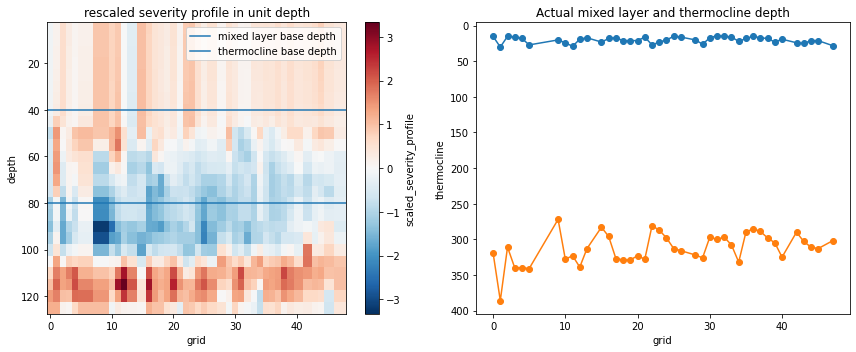

In [17]:
plt.figure(figsize=(12,5))
plt.subplot(121)
data = rescaled_event_dataset.isel(event=0,time=0).dropna("grid")
data.scaled_severity_profile.plot(y='depth')
plt.gca().invert_yaxis()
plt.title("rescaled severity profile in unit depth")
plt.axhline(y = 8*5, label='mixed layer base depth')
plt.axhline(y = 16*5, label='thermocline base depth')
plt.legend()
plt.subplot(122)
data.mld.plot(marker='o')
data.thermocline.plot(marker='o')
plt.gca().invert_yaxis()
plt.title("Actual mixed layer and thermocline depth")
plt.tight_layout()

In [16]:
# Save the event's rescaled MHW profiles to netcdf file
#rescaled_event_dataset.to_netcdf(f'./rescaled_mhw_{mhw_ind}_profiles_severity.nc') 

### Loop over all 536 MHW events

In [ ]:
# Load severity index
ds2 = xr.open_mfdataset('/your_severity_index_data_path/GLORYS_intp5m_temp_mhw_severity_intensity.mixedLayer_thermocline_pycnocline_depth.*.1993.2020.nc')
severity = ds2.mhw_severity_index
severity = severity.sel(depth=slice(0,1000))
# Load mixed layer depth and thermocline depth
mld = ds2.mixed_layer_depth
tc = ds2.thermocline_base_depth
# Extract spatial coordinates
latitudes = severity.lat.values
depths = severity.depth.values
longitudes = severity.lon.values

# Loop for all events
for mhw_ind in range(1):#len(file_list_sorted)
    df =pd.read_csv(file_list_sorted[mhw_ind],header=None)
    rescaled_event_dataset = apply_rescaling_to_single_event(df,severity,mld,tc,mhw_ind)
    plt.figure(figsize=(12,5))
    plt.subplot(121)
    data = rescaled_event_dataset.isel(event=0,time=0).dropna("grid")
    data.scaled_severity_profile.plot(y='depth')
    plt.gca().invert_yaxis()
    plt.title("rescaled severity profile in unit depth")
    plt.axhline(y = 8*5, label='mixed layer base depth')
    plt.axhline(y = 16*5, label='thermocline base depth')
    plt.legend()
    plt.subplot(122)
    data.mld.plot(marker='o')
    data.thermocline.plot(marker='o')
    plt.gca().invert_yaxis()
    plt.title("Actual mixed layer and thermocline depth")
    plt.tight_layout()
    #rescaled_event_dataset.to_netcdf('./rescaled_mhw_{mhw_ind}_profiles_severity.nc') 
